In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('../data/train.csv')

# Ver las primeras filas
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
# Información general: tipos de datos, cuántos no-nulos hay
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [22]:
# Estadísticas descriptivas de las variables numéricas
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
# Cuántos valores faltantes hay por columna
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

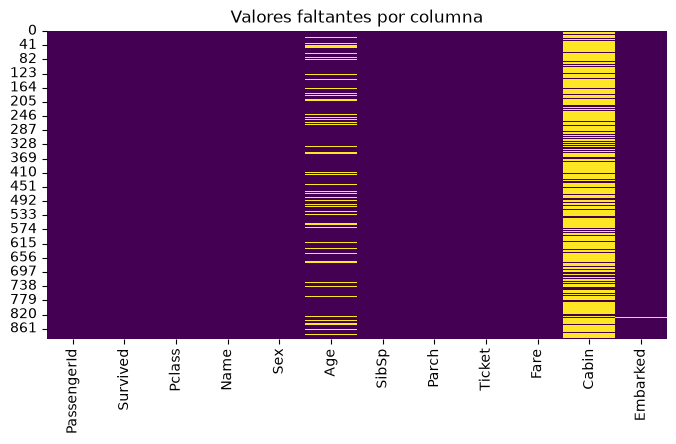

In [24]:
# Visualizarlo de un vistazo
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Valores faltantes por columna')
plt.show()

Tasa general de supervivencia: 38.4%


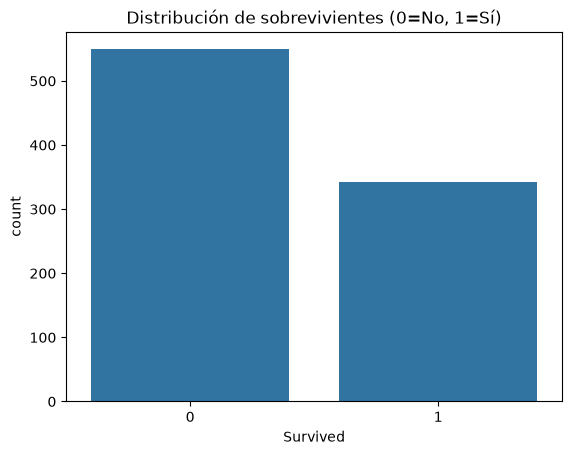

In [25]:
# Tasa de supervivencia general (obs la variable Survived es 0=No, 1=Sí)

survived_rate = df['Survived'].mean() * 100
print(f"Tasa general de supervivencia: {survived_rate:.1f}%")

sns.countplot(data=df, x='Survived')
plt.title('Distribución de sobrevivientes (0=No, 1=Sí)')
plt.show()

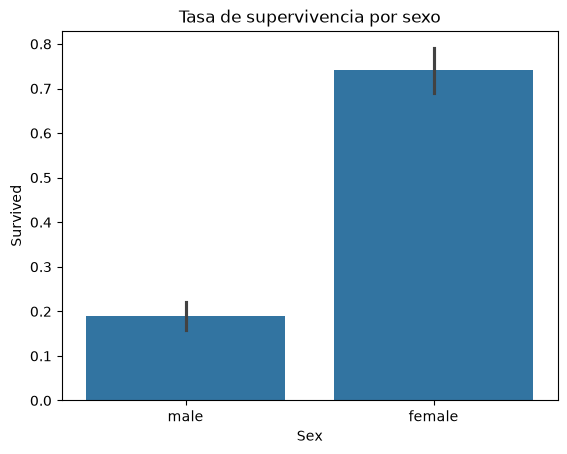

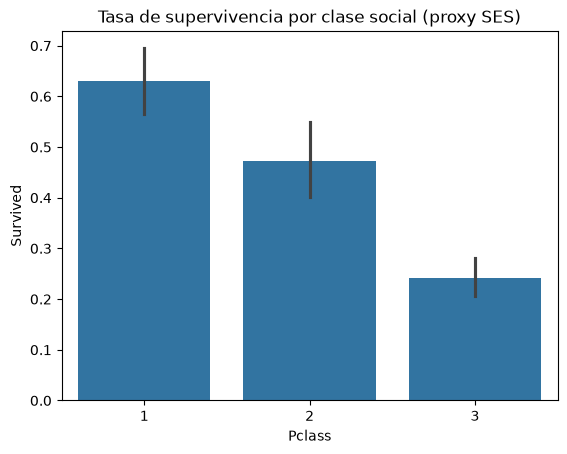

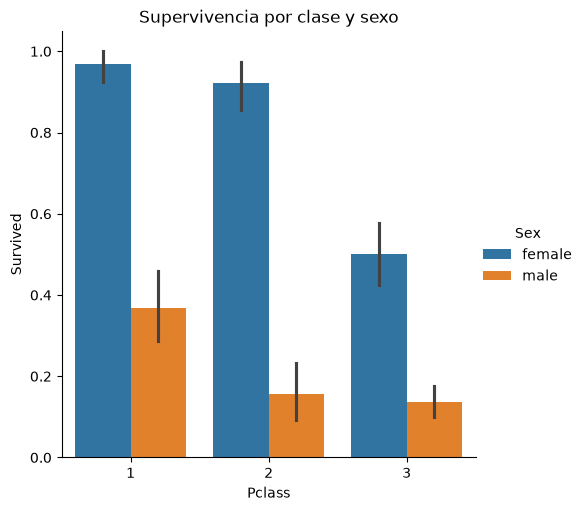

In [26]:
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Tasa de supervivencia por sexo')
plt.show()

sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Tasa de supervivencia por clase social (proxy SES)')
plt.show()

# Combinando ambas variables
sns.catplot(data=df, x='Pclass', y='Survived', hue='Sex', kind='bar')
plt.title('Supervivencia por clase y sexo')
plt.show()

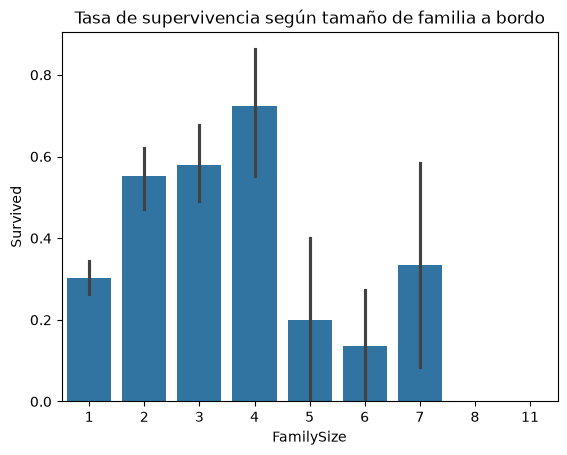

In [27]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 por el propio pasajero

sns.barplot(data=df, x='FamilySize', y='Survived')
plt.title('Tasa de supervivencia según tamaño de familia a bordo')
plt.show()

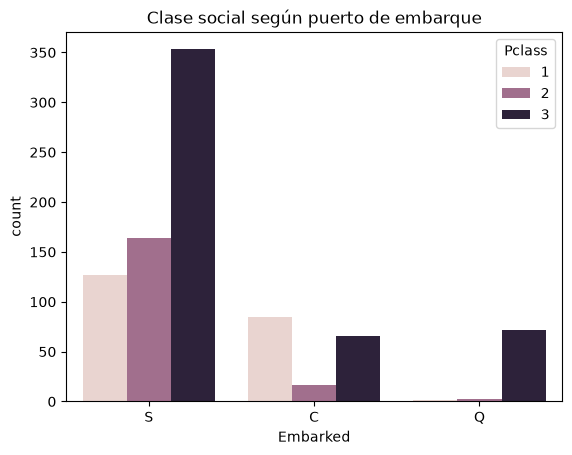

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [28]:
sns.countplot(data=df, x='Embarked', hue='Pclass')
plt.title('Clase social según puerto de embarque')
plt.show()

df.groupby('Embarked')['Survived'].mean()